In [23]:
import dpluspy
import demes 
import moments
import msprime
import numpy as np

In [1]:
# Define paths to models
model0_file = "notebook_models/graph0.yaml"
params0_file = "notebook_models/params0.yaml"
model1_file = "notebook_models/graph1.yaml"
model1_null_file = "notebook_models/graph1_null_params.yaml"
params1_file = "notebook_models/params1.yaml"

true_model_file = model0_file

# Set up models, parameters and write them to disk.
model0_str = """time_units: generations
demes:
- name: popX
  epochs:
  - {end_time: 0, start_size: 15000}
"""

params0_str = """parameters: 
- name: N_X
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
"""

model1_str = """time_units: generations
demes:
- name: popX
  epochs:
  - {end_time: 2000, start_size: 15000}
  - {end_time: 0, start_size: 5000}
"""

model1_null_str = """time_units: generations
demes:
- name: popX
  epochs:
  - {end_time: 2000, start_size: 15000}
  - {end_time: 0, start_size: 15000}
"""

params1_str = """parameters: 
- name: N_X0
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            0: start_size
- name: T_0
  lower_bound: 10
  upper_bound: 5e4
  values: 
    - demes: 
        popX: 
          epochs: 
            0: end_time
- name: N_X1
  lower_bound: 10
  upper_bound: 1e5
  values: 
    - demes: 
        popX: 
          epochs: 
            1: start_size
"""

with open(model0_file, "w") as fout:
    fout.write(model0_str)
with open(params0_file, "w") as fout:
    fout.write(params0_str)

with open(model1_file, "w") as fout:
    fout.write(model1_str)
with open(params1_file, "w") as fout:
    fout.write(params1_str)

with open(model1_null_file, "w") as fout:
    fout.write(model1_null_str)

In [25]:
# Parameters
r = 1e-8
u = 1.3e-8
u_std = 2e-9
L = int(5e6)
n_reps = 100
pop_ids = ["popX"]
samples = {pop_id: 1 for pop_id in pop_ids}
bins = np.logspace(-6, -2, 17)

In [26]:
# Define simulation and D+ parsing functions

def simulate():
    graph = demes.load(true_model_file)
    demog = msprime.Demography.from_demes(graph)
    tss = msprime.sim_ancestry(
        demography=demog,
        samples=samples,
        sequence_length=L,
        recombination_rate=r,
        num_replicates=n_reps,
    )
    mtss = [msprime.sim_mutations(ts, np.random.normal(u, u_std)) for ts in tss]
    return mtss


def parse_stats(mtss):
    # Parse statistics from simulation results
    intervals = [[1, L + 1, L + 1]]
    pop_mapping = {x: [x] for x in samples} 
    stats = dict()
    for ii, ts in enumerate(mtss):
        if ii == 0:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=True,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
        else:
            stats_ii = dpluspy.parsing.parse_stats(
                ts, 
                get_denoms=False,
                pop_mapping=pop_mapping, 
                r=r, 
                r_bins=bins, 
                intervals=intervals,
                chrom=ii, 
                ts_sample_ids=pop_ids, 
                overhang=None,
                verbose=False
            )
            for jj in range(len(intervals)):
                stats_ii[(ii, jj)]["denoms"] = stats[(0, jj)]["denoms"]
        stats.update(stats_ii)
    return stats

In [27]:
# Run simulations
mtss = simulate()

# Parse statistics and perform the bootstrap
stats = parse_stats(mtss)
bootreps = dpluspy.bootstrapping.get_bootstrap_reps(
    stats, num_reps=100, weighted=False)
varcovs = dpluspy.bootstrapping.compute_varcovs(bootreps)
means = dpluspy.bootstrapping.means_across_regions(stats)

KeyboardInterrupt: 

In [ ]:
def fit_model(ms, vcs, graph_file, param_file, out_file):
    """
    Fit a model, forcing convergence to within 1% LL.
    """
    ll_log = []
    thresh = 0.01
    counter = 0
    max_tries = 10
    converged = False
    while not converged:
        ret = dpluspy.inference.optimize(
            graph_file,
            param_file,
            ms,
            vcs,
            pop_ids=pop_ids,
            bins=bins,
            u=u,
            perturb=0.05,
            method="powell",
            log=True,
            max_iter=100,
            verbose=200,
            output=out_file,
            overwrite=True
        )
        ll = ret[-1]
        if counter > 0:
            diffs = np.abs((np.array(ll_log) - ll) / ll)
            if np.any(diffs < thresh):
                converged = True
            if counter > max_tries:
                raise ValueError("Failed to obtain convergence")
        ll_log.append(ll)
        counter += 1
    return ret

In [ ]:
# Fit the null and underlying (complex) models; force ll1 > ll0
out0 = "notebook_models/model0_fit0.yaml"
out1 = "notebook_models/model0_fit1.yaml"
pnames0, params0, ll0 = fit_model(
    means, varcovs, model0_file, params0_file, out0)
ll1 = -1e10
max_tries = 2
tries = 0
while ll1 <= ll0:
    pnames1, params1, ll1 = fit_model(
        means, varcovs, model1_null_file, params1_file, out1)
    tries += 1
    if tries > max_tries:
        raise ValueError("Cannot achieve ll1 > ll0")

[21-07-25 09:39:03] Fitting D+ to data for ['popX']
Call         LL [       N_X]
init          - [  1.49e+04]
Finished with flag 0
Log-likelihood:	-0.07
Fitted parameters:
N_X	1.53e+04
[21-07-25 09:39:04] Fitting D+ to data for ['popX']
Call         LL [       N_X]
init          - [  1.52e+04]
Finished with flag 0
Log-likelihood:	-0.07
Fitted parameters:
N_X	1.53e+04
[21-07-25 09:39:05] Fitting D+ to data for ['popX']
Call         LL [      N_X0       T_0      N_X1]
init          - [  1.56e+04  2.05e+03  1.53e+04]
200       -0.07 [  1.54e+04     1e+04  1.53e+04]
400       -0.06 [  1.54e+04  3.98e+03   1.5e+04]
600       -0.12 [  1.54e+04  1.66e+03  1.38e+04]
800       -0.03 [  1.54e+04  5.67e+02  1.05e+04]
1000      -0.02 [  1.55e+04  2.64e+02  6.25e+03]
Finished with flag 0
Log-likelihood:	-0.02
Fitted parameters:
N_X0	1.55e+04
T_0	1.95e+02
N_X1	4.73e+03
[21-07-25 09:39:55] Fitting D+ to data for ['popX']
Call         LL [      N_X0       T_0      N_X1]
init          - [  1.53e+04  1.

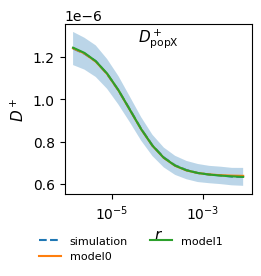

In [ ]:
# Plot model fits
model0 = dpluspy.inference.compute_bin_stats(out0, bins=bins, u=u, 
    sampled_demes=pop_ids)
model1 = dpluspy.inference.compute_bin_stats(out1, bins=bins, u=u, 
    sampled_demes=pop_ids)
dpluspy.plotting.plot_D_plus_curves(models=[model0, model1], bins=bins, 
    pop_ids=pop_ids, means=means, varcovs=varcovs, ax_size=2.5,
    labels=["simulation", "model0", "model1"])

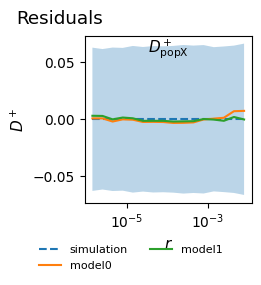

In [ ]:
# Plot errors against simulated data
res0 = [(m - s) / s for m, s in zip(model0, means)]
res1 = [(m - s) / s for m, s in zip(model1, means)]
zeros = [np.array([0])] * len(means)
vs = [v / s ** 2 for v, s in zip(varcovs, means)]
dpluspy.plotting.plot_D_plus_curves(models=[res0, res1], bins=bins, 
    varcovs=vs, means=zeros, pop_ids=pop_ids, ax_size=2.5,
    labels=["simulation", "model0", "model1"],
    title="Residuals")

In [ ]:
# Summarize fitted parameters
print(f"Model 0 (null) ll = {ll0:.3}")
print("Param\tvalue")
for name, val in zip(pnames0, params0):
    print(f"{name}\t{val:.3}")

print(f"\nModel 1 (full, underlying) ll = {ll1:.3}")
print("Param\tvalue")
for name, val in zip(pnames1, params1):
    print(f"{name}\t{val:.3}")

# We have a single nested parameter which is not at a boundary (m_XY)
weights = (0, 1)
D_naive = 2 * (ll1 - ll0)
p_naive = moments.Godambe.sum_chi2_ppf(D_naive, weights=weights)

print("\nNaive (unadjusted) LR statistic:")
print(f"D =\t{D_naive:.3}")
print(f"p =\t{p_naive:.3}")

Model 0 (null) ll = -0.0708
Param	value
N_X	1.53e+04

Model 1 (full, underlying) ll = -0.0205
Param	value
N_X0	1.55e+04
T_0	1.91e+02
N_X1	4.5e+03

Naive (unadjusted) LR statistic:
D =	0.101
p =	0.751


In [ ]:
# Compute the LRT adjustment at model 1 MLE parameters

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = params1
steps = p_lrt[1:] * 0.01
nested_idx = np.array([1, 2])

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_X0	1.55e+04	False	---
T_0	1.91e+02	True	1.91
N_X1	4.5e+03	True	45.0

adj =	0.127
D_adj =	0.0127
p =	0.91


In [ ]:
# Compute the LRT adjustment at model 0 MLE parameters

# Set up complex model arguments
_, __, model_args = dpluspy.uncerts.set_up_model_args(
    model1_file, params1_file, bins=bins, pop_ids=pop_ids, u=u)

p_lrt = np.concatenate([params0, [1, params0[0]]])
steps = p_lrt[1:] * 0.01

# Print a summary of the parameter setup
print("Param\tvalue\tnested?\tstep")
nest_idx = 0
for ii, (name, val) in enumerate(zip(pnames1, p_lrt)):
    nested = True if ii in nested_idx else False
    if nested:
        step = f"{steps[nest_idx]:.3}"
        nest_idx += 1
    else:
        step = "---"
    print(f"{name}\t{val:.3}\t{nested}\t{step}")

adj = dpluspy.uncerts.LRT_adjust(
    p_lrt, 
    model_args, 
    means, 
    varcovs, 
    bootreps, 
    nested_idx, 
    steps=steps,
    verbose=0
)

# Compute the adjusted LR test statistic
D_adj = adj * D_naive
p_adj = moments.Godambe.sum_chi2_ppf(D_adj, weights=weights)

print(f"\nadj =\t{adj:.3}")
print(f"D_adj =\t{D_adj:.3}")
print(f"p =\t{p_adj:.3}")

Param	value	nested?	step
N_X0	1.53e+04	False	---
T_0	1.0	True	0.01
N_X1	1.53e+04	True	1.53e+02

adj =	7.93e+03
D_adj =	7.98e+02
p =	0.0


In [28]:
# Evaluate naive D across some bootstrap replicates 
rep_lls = []
for ii in range(5):
    pnames0, params0, ll0 = fit_model(
        bootreps[ii], varcovs, model0_file, params0_file, None)
    pnames1, params1, ll1 = fit_model(
        bootreps[ii], varcovs, out1, params1_file, None)
    if ll1 < ll0:
        continue 
    rep_lls.append([ll0, ll1])

[21-07-25 09:47:45] Fitting D+ to data for ['popX']
Call         LL [       N_X]
init          - [  1.43e+04]
Finished with flag 0
Log-likelihood:	-0.23
Fitted parameters:
N_X	1.57e+04
[21-07-25 09:47:46] Fitting D+ to data for ['popX']
Call         LL [       N_X]
init          - [  1.56e+04]
Finished with flag 0
Log-likelihood:	-0.23
Fitted parameters:
N_X	1.57e+04
[21-07-25 09:47:47] Fitting D+ to data for ['popX']
Call         LL [      N_X0       T_0      N_X1]
init          - [  1.55e+04  1.94e+02  4.54e+03]
200       -0.16 [  1.58e+04  3.86e+02  8.86e+03]
400       -0.15 [  1.58e+04  9.03e+02  1.17e+04]
Finished with flag 0
Log-likelihood:	-0.15
Fitted parameters:
N_X0	1.58e+04
T_0	8.01e+02
N_X1	1.11e+04
[21-07-25 09:48:08] Fitting D+ to data for ['popX']
Call         LL [      N_X0       T_0      N_X1]
init          - [  1.62e+04  1.95e+02   4.4e+03]
200       -0.16 [  1.58e+04  4.72e+02  8.75e+03]
400       -0.15 [  1.58e+04  8.05e+02   1.1e+04]
Finished with flag 0
Log-likeli

In [35]:
rep_lls = np.array(rep_lls)
rep_Ds = 2 * (rep_lls[:, 1] - rep_lls[:, 0])
print(rep_Ds)

[0.15285085 0.03318718 0.90089969 0.05077054 0.37087356]
